# Statistical significance checks

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import logging

from gsm_benchmarker.results_analyser import MultiVariantMultiModelResultsAnalyser
from gsm_benchmarker.results_analyser.prompt_effect_analyser import PromptEffectAnalyser
from gsm_benchmarker.results_analyser.plotting_utils import plot_glmm


logger = logging.getLogger('notebook')

plt.style.use('seaborn-v0_8-muted')
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
pp = Path("../../../../data/gsm-symbolic/outputs").resolve()

p_standard = pp / "mini_20x50x4__14_11/final"
p_sep = pp / 'mini_sep_new__20x50__20_12/final'
p_code = pp / 'mini_code_output_20x50__05_12/final'

p_standard_full = pp / "default_full__06_02/final"
p_code_full = pp / 'code_full__09_02/final'

In [3]:
mres_standard = MultiVariantMultiModelResultsAnalyser(p_standard)
mres_code = MultiVariantMultiModelResultsAnalyser(p_code)

mres_standard_full = MultiVariantMultiModelResultsAnalyser(p_standard_full)
mres_code_full = MultiVariantMultiModelResultsAnalyser(p_code_full)


  0%|          | 0/3 [00:00<?, ?it/s]/home/guests2/dkd/code/gsm-symbolic-benchmarking/src/gsm_benchmarker/results_analyser/multi_model.py:81: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(full_data_dict.values(), keys=full_data_dict.keys(), names=['model', 'old_index'])
 33%|███▎      | 1/3 [00:00<00:01,  1.25it/s]/home/guests2/dkd/code/gsm-symbolic-benchmarking/src/gsm_benchmarker/results_analyser/multi_model.py:81: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(ful

In [4]:
pea_code = PromptEffectAnalyser(mres_standard, mres_code, "Code output prompt (pilot)")
pea_code_full = PromptEffectAnalyser(mres_standard_full, mres_code_full, "Code output prompt")

### Modelling question difficulty

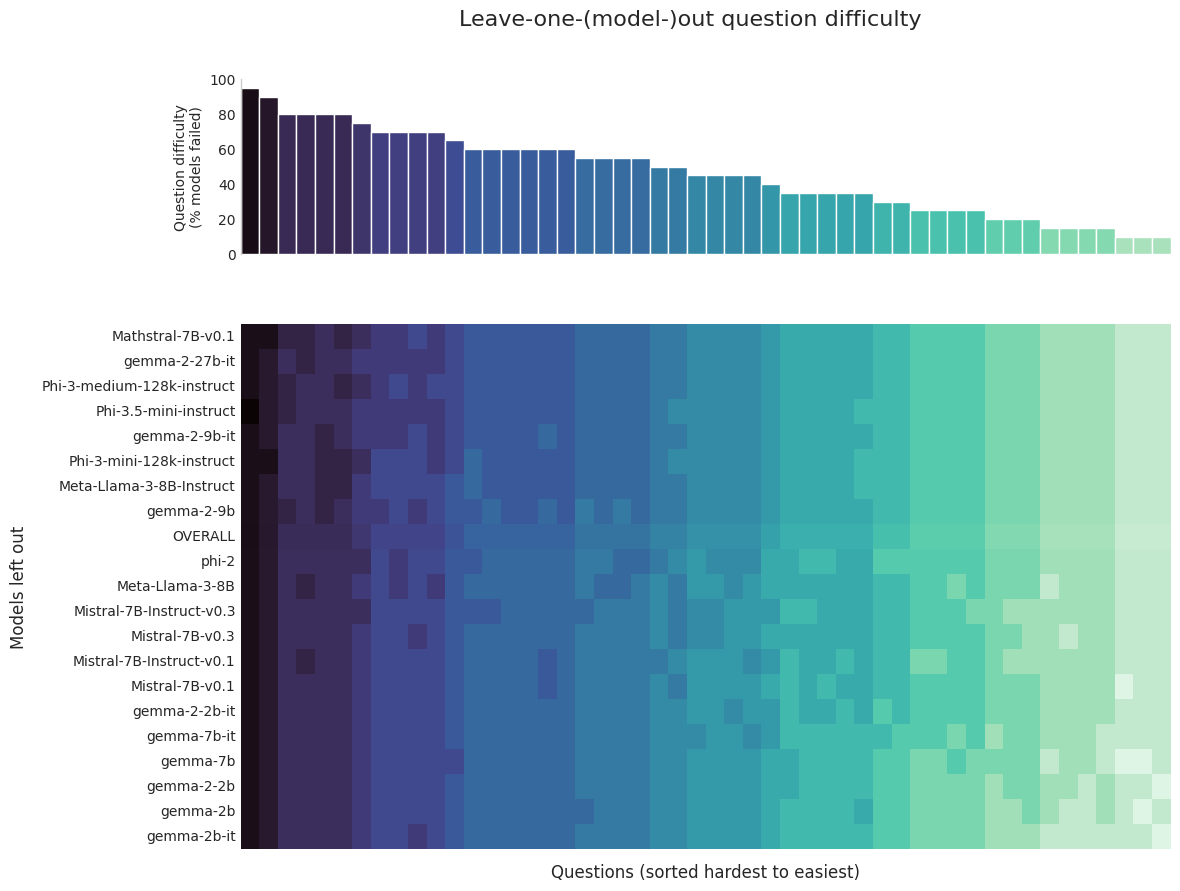

In [5]:
_ = pea_code._baseline_mres.plot_question_difficulty_per_model()

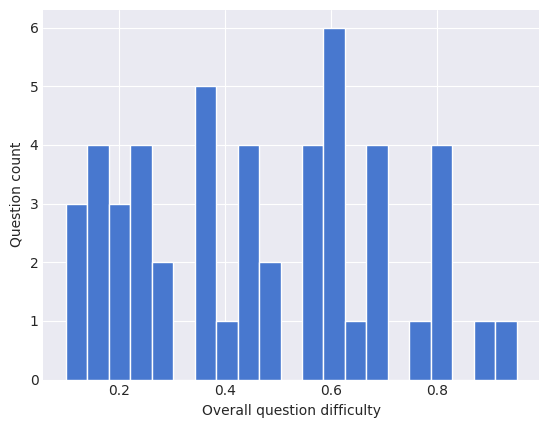

In [6]:
_ = pea_code._baseline_mres.plot_question_difficulty_histogram()

## Question 1
Are the accuracy drops reported in the GSM-Symbolic paper actually significant?

Evaluating significance of accuracy drop on 'main' variant vs 'GSM8K' variant with GSM-Symbolic prompt.

### 1A: Pilot run
Checking on a subset of the benchmark first. Projecting results to the full dataset with alpha = 20%.

50/100 questions, 20/50 template variations -> 1000/5000 total questions in the 'main variant' (20% of the benchmark) (+ 50 questions in the original GSM8K variant)

In [7]:
PROJECTED_ALPHA = 0.2

In [8]:
variant_effect_df = mres_standard.analyse_variant_effect('main')

Mistral-7B-v0.1, correct_strict: GLMM fitting failed: Error: Response is constant

Mistral-7B-v0.3, correct_strict: GLMM fitting failed: Error: Response is constant

Phi-3-medium-128k-instruct, correct_strict: GLMM fitting failed: Error: Response is constant

Phi-3.5-mini-instruct, correct_strict: GLMM fitting failed: Error: Response is constant

gemma-2-2b, correct_strict: GLMM fitting failed: Error: Response is constant

phi-2, correct_strict: GLMM fitting failed: Error: Response is constant



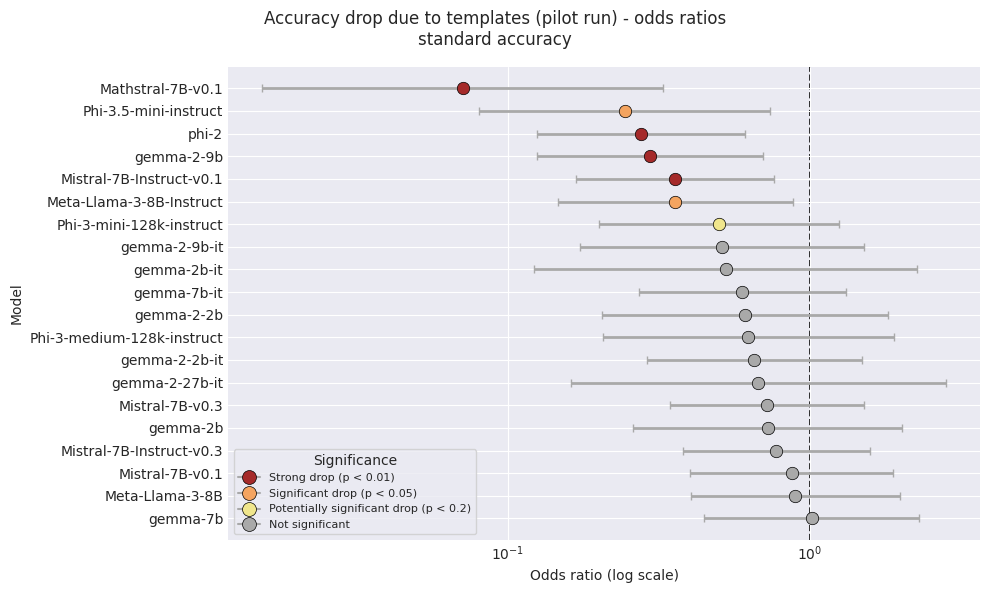

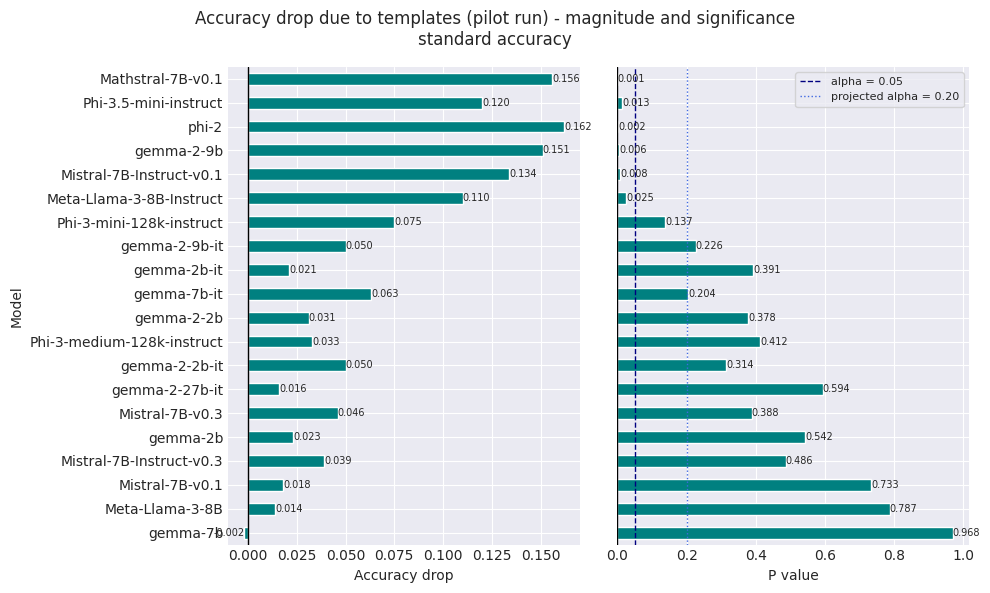

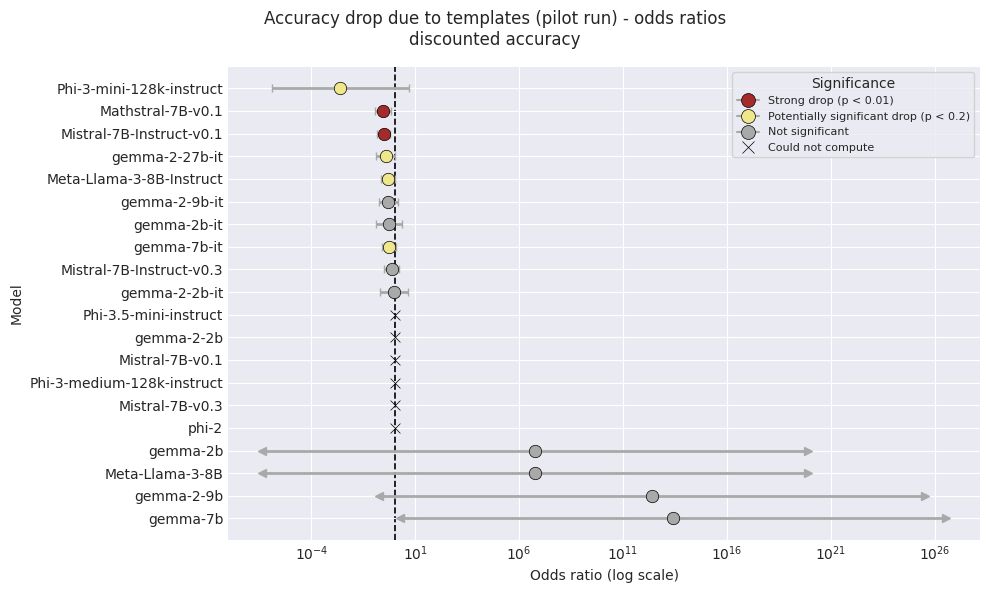

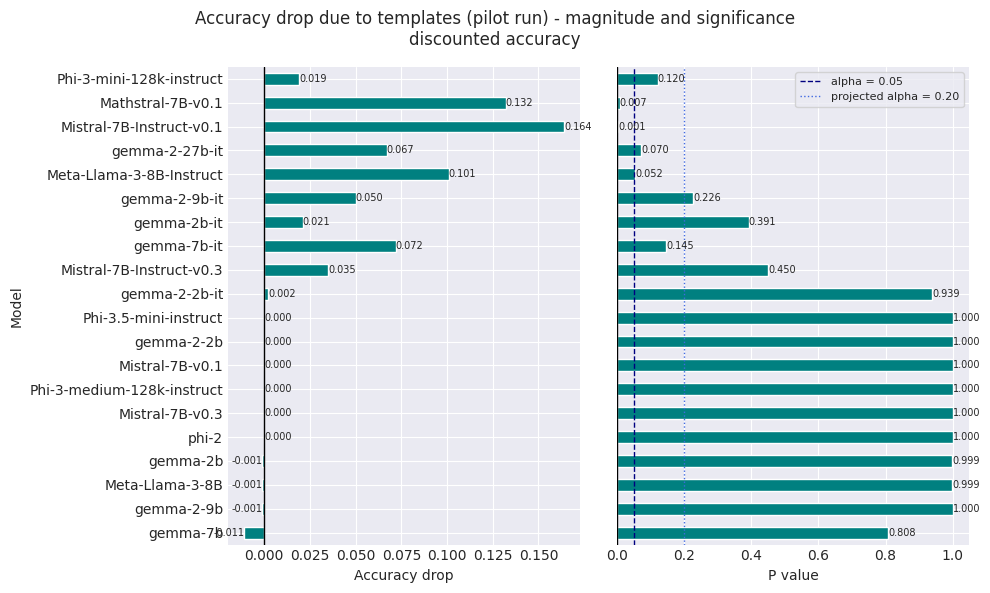

In [9]:
_ = plot_glmm(
    variant_effect_df,
    'accuracy_drop',
    title="Accuracy drop due to templates (pilot run)",
    projected_alpha=PROJECTED_ALPHA
)


#### Candidate models
Models which, based on the pilot results, are worth checking on the full dataset.

In [10]:
candidate_models = variant_effect_df[variant_effect_df.p_value < PROJECTED_ALPHA].index.get_level_values('model').unique().tolist()
candidate_models

['Mathstral-7B-v0.1',
 'Meta-Llama-3-8B-Instruct',
 'Mistral-7B-Instruct-v0.1',
 'Phi-3-mini-128k-instruct',
 'Phi-3.5-mini-instruct',
 'gemma-2-27b-it',
 'gemma-2-9b',
 'gemma-7b-it',
 'phi-2']

### 1B: Full benchmark
Re-running the tests on the full benchmark (100 + 5000 questions) with the identified candidate models.

In [11]:
variant_effect_df_full = mres_standard_full.analyse_variant_effect('main', models=candidate_models)
variant_effect_df_full

gemma-2-9b, correct_strict: GLMM fitting failed: Error: Response is constant

phi-2, correct_strict: GLMM fitting failed: Error: Response is constant



estimate   p_value       std_err  \
model                    metric                                          
Mathstral-7B-v0.1        discounted  -0.560831  0.031656  2.610055e-01   
                         standard    -0.866908  0.007704  3.253224e-01   
Meta-Llama-3-8B-Instruct discounted  -0.274185  0.337463  2.858502e-01   
                         standard    -0.533992  0.090636  3.155888e-01   
Mistral-7B-Instruct-v0.1 discounted  -0.415775  0.148987  2.881088e-01   
                         standard    -0.377456  0.192953  2.899291e-01   
Phi-3-mini-128k-instruct discounted   0.774724  0.479808  1.096393e+00   
                         standard    -0.646912  0.053933  3.356438e-01   
Phi-3.5-mini-instruct    discounted  24.048460  0.999984  1.178983e+06   
                         standard    -1.056192  0.003318  3.596578e-01   
gemma-2-27b-it           discounted  -0.909907  0.003230  3.089757e-01   
                         standard    -0.879657  0.043872  4.364862e-01   
gemma-2-9b               discounted        NaN  1.000000           NaN   
                         standard    -1.257998  0.000068  3.158398e-01   
gemma-7b-it              discounted  -0.589047  0.042471  2.903316e-01   
                         standard    -0.513559  0.077765  2.911653e-01   
phi-2                    discounted        NaN  1.000000           NaN   
                         standard    -0.552473  0.089620  3.254803e-01   

                                     accuracy_drop  
model                    metric                     
Mathstral-7B-v0.1        discounted         0.0834  
                         standard           0.0906  
Meta-Llama-3-8B-Instruct discounted         0.0334  
                         standard           0.0560  
Mistral-7B-Instruct-v0.1 discounted         0.0486  
                         standard           0.0442  
Phi-3-mini-128k-instruct discounted        -0.0086  
                         standard           0.0632  
Phi-3.5-mini-instruct    discounted        -0.0002  
                         standard           0.0964  
gemma-2-27b-it           discounted         0.0930  
                         standard           0.0514  
gemma-2-9b               discounted         0.0000  
                         standard           0.1386  
gemma-7b-it              discounted         0.0674  
                         standard           0.0588  
phi-2                    discounted         0.0000  
                         standard           0.0502

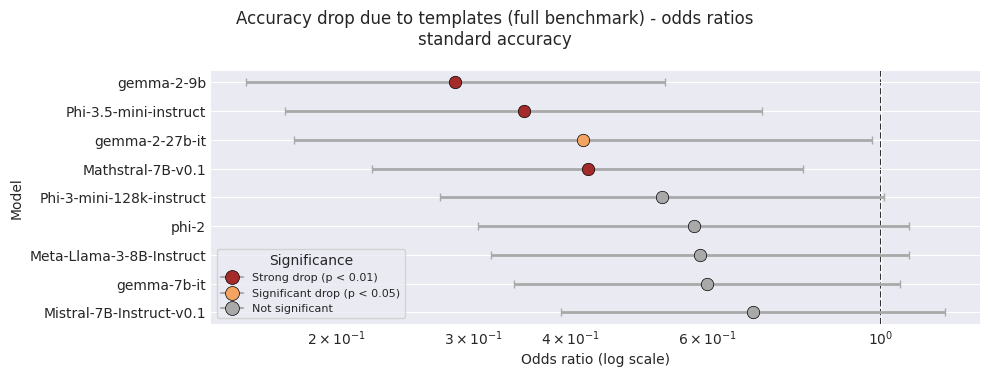

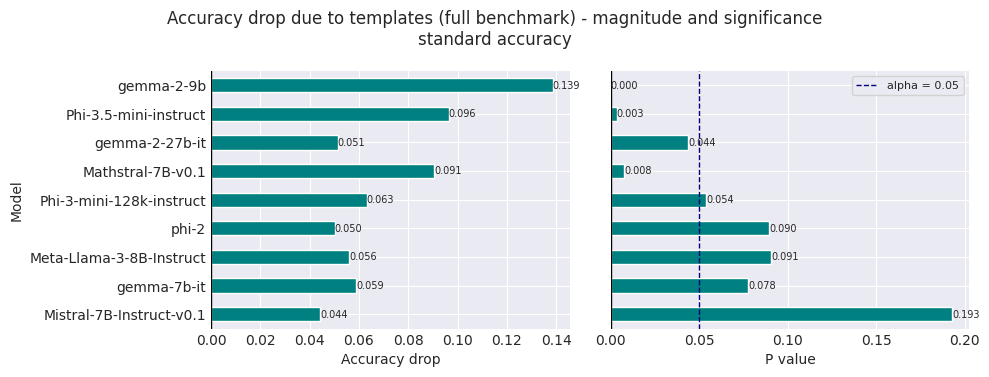

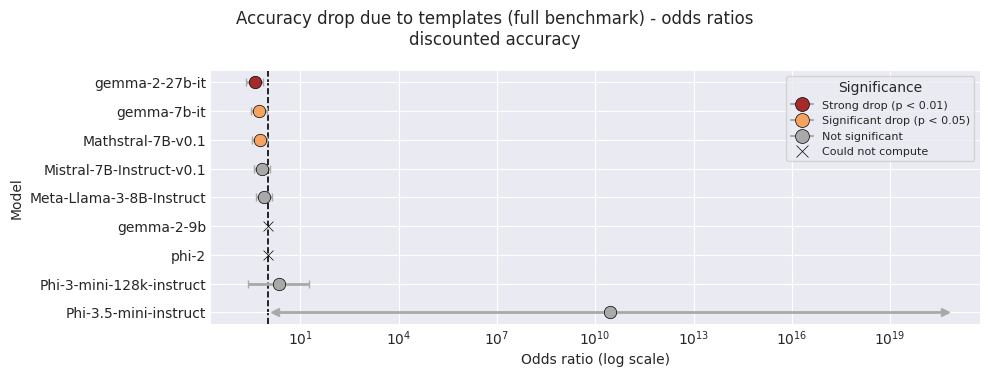

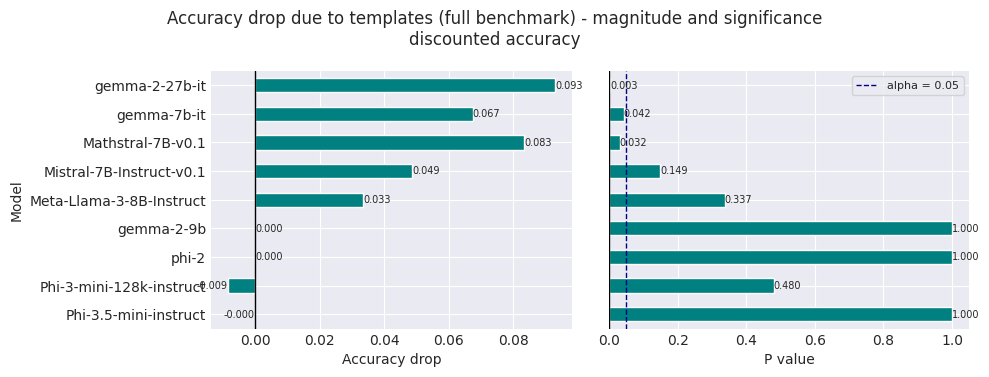

In [12]:
_ = plot_glmm(
    variant_effect_df_full,
    'accuracy_drop',
    title="Accuracy drop due to templates (full benchmark)"
)

In [13]:
significant_models = variant_effect_df_full[variant_effect_df_full.p_value < 0.05].index.get_level_values('model').unique().tolist()
significant_models

['Mathstral-7B-v0.1',
 'Phi-3.5-mini-instruct',
 'gemma-2-27b-it',
 'gemma-2-9b',
 'gemma-7b-it']

## Question 2
Does code prompt remove the variant dependency?

Evaluating significance of accuracy drop on 'main' variant vs 'GSM8K' variant with code prompt.

In [14]:
variant_effect_df_full_code = mres_code_full.analyse_variant_effect('main', models=significant_models)

gemma-7b-it, correct: GLMM fitting failed: Error: Response is constant

gemma-7b-it, correct_strict: GLMM fitting failed: Error: Response is constant



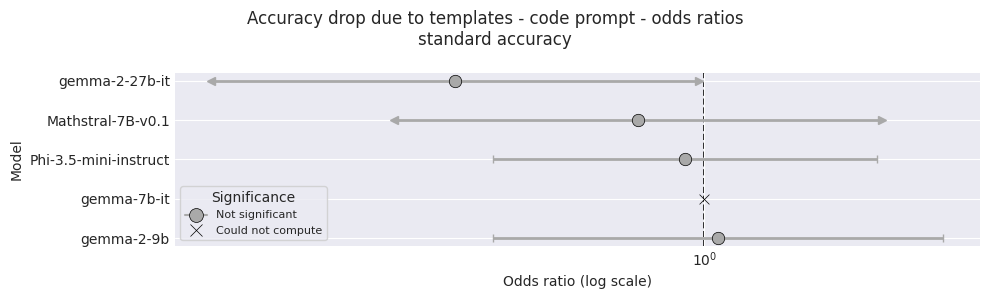

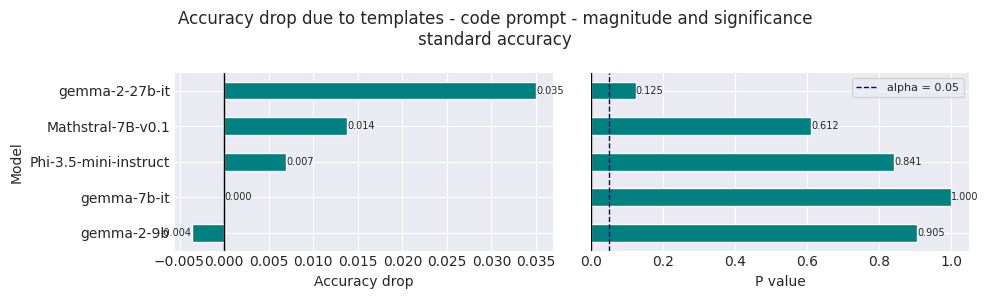

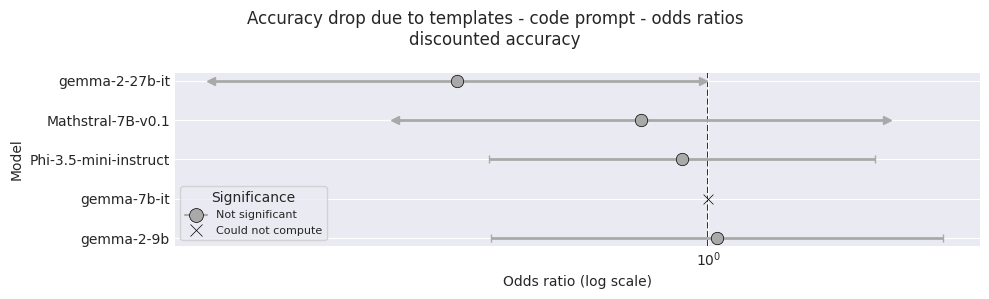

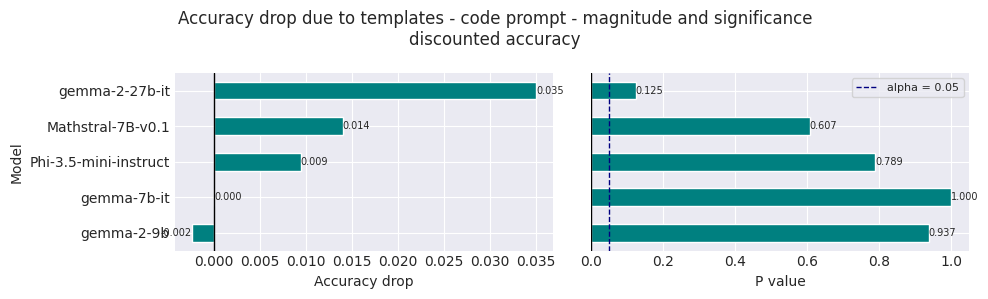

In [15]:
_ = plot_glmm(
    variant_effect_df_full_code,
    'accuracy_drop',
    title="Accuracy drop due to templates - code prompt"
)

### Code prompt evaluation
Does code prompt result in significant performance changes?

Evaluating performance on 'main' variant with the code prompt vs GSM-Symbolic prompt.

In [16]:
acc_change_df = pea_code_full.analyse_accuracy_change_significance(variant='main', models=significant_models)
acc_change_df

estimate        p_value        std_err  \
model                 metric                                                
Mathstral-7B-v0.1     discounted   1.829744  1.608594e-221       0.057591   
                      standard     0.699352   3.449329e-30       0.061257   
Phi-3.5-mini-instruct discounted  11.654358   4.737519e-18       1.345843   
                      standard    -0.383485   3.538738e-12       0.055142   
gemma-2-27b-it        discounted   4.308039   0.000000e+00       0.082072   
                      standard     0.525246   7.265189e-12       0.076652   
gemma-2-9b            discounted  26.960996   9.839907e-01    1343.613350   
                      standard     0.260242   4.559497e-06       0.056771   
gemma-7b-it           discounted -30.725878   9.997349e-01   92463.603830   
                      standard   -33.466951   9.999176e-01  324154.765336   

                                  mean_diff  median_diff  
model                 metric                              
Mathstral-7B-v0.1     discounted     0.2694         0.21  
                      standard       0.0768         0.04  
Phi-3.5-mini-instruct discounted     0.6604         0.78  
                      standard      -0.0506        -0.04  
gemma-2-27b-it        discounted     0.6080         0.74  
                      standard       0.0364         0.00  
gemma-2-9b            discounted     0.6024         0.76  
                      standard       0.0322         0.00  
gemma-7b-it           discounted    -0.2026        -0.09  
                      standard      -0.2112        -0.10

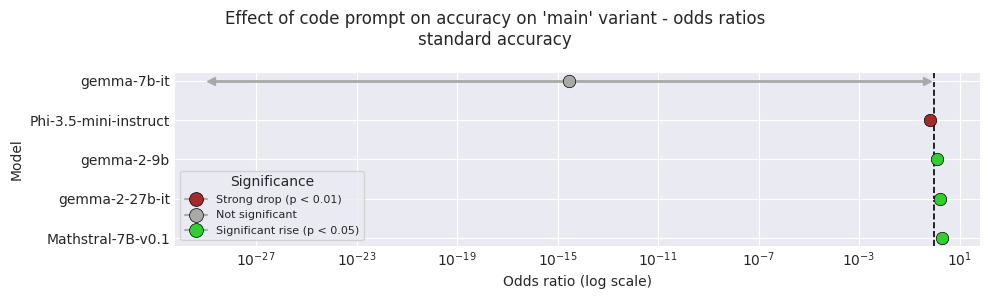

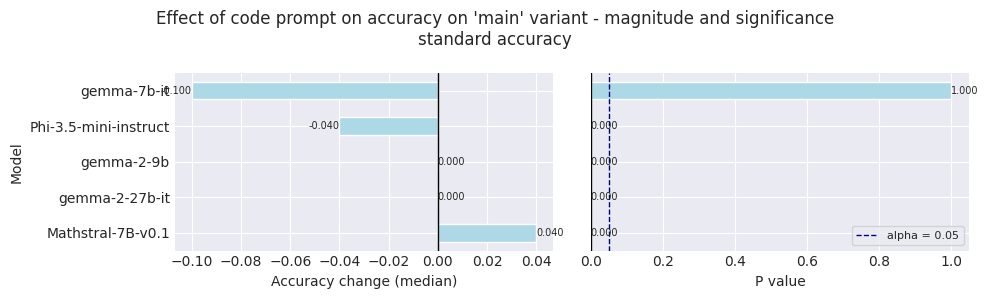

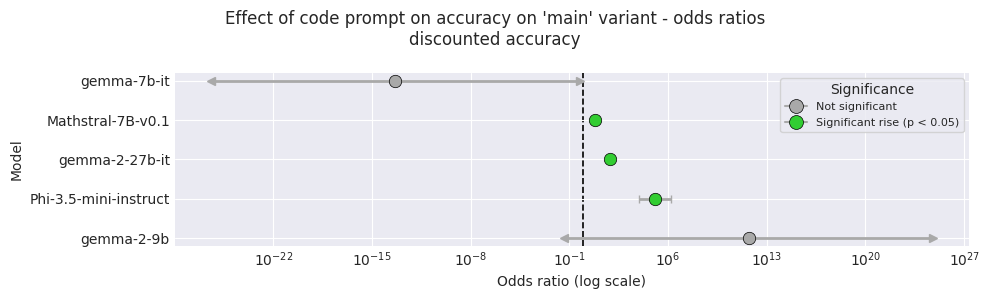

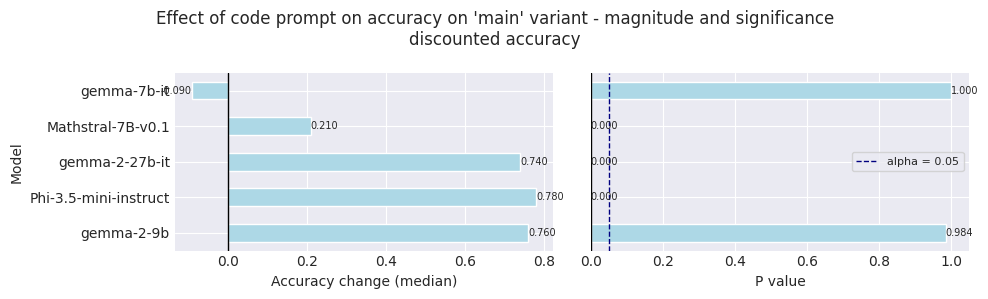

In [17]:
_ = plot_glmm(
    acc_change_df,
    'median_diff',
    bars_value_ylabel='Accuracy change (median)',
    title="Effect of code prompt on accuracy on 'main' variant",
    bar_colour='lightblue'
)